In [1]:
import CalculatedFieldSubroutines as cfs

#

import numpy as np

import pandas as pd

#

import matplotlib.pyplot as plt

In [2]:
gmID_list = cfs.list_whitelisted_gmIDs()

gmID_dfs_list = [ cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = gmID, moving_window = 0 ) for gmID in gmID_list ]

all_gmIDs_df = pd.concat( gmID_dfs_list )

del gmID_dfs_list

In [3]:
all_gmIDs_df_manual = all_gmIDs_df[ all_gmIDs_df[ 'BinaryDrivingMode' ] == 0 ]

all_gmIDs_df_auto = all_gmIDs_df[ all_gmIDs_df[ 'BinaryDrivingMode' ] == 1 ]

#

all_gmIDs_df_nondisengagement_expanded = all_gmIDs_df[ all_gmIDs_df[ 'BinaryDisengagementExpanded' ] == 0 ]

all_gmIDs_df_disengagement_expanded = all_gmIDs_df[ all_gmIDs_df[ 'BinaryDisengagementExpanded' ] == 1 ]    

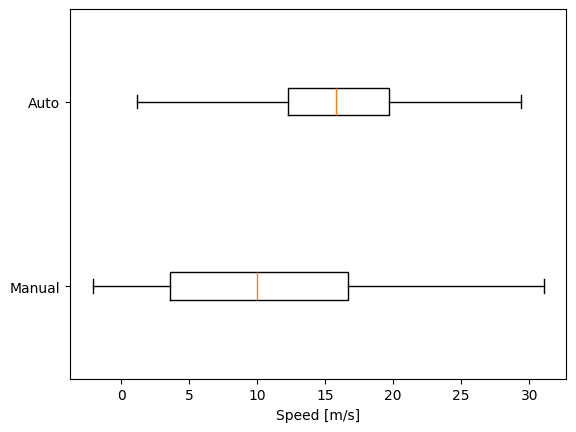

In [9]:
plt.boxplot( [ all_gmIDs_df_manual[ 'speedMps' ], all_gmIDs_df_auto[ 'speedMps' ] ], vert = False, showfliers = False )

plt.yticks( [ 1, 2 ], [ 'Manual', 'Auto' ] )

plt.xlabel( 'Speed [m/s]' )

plt.show()

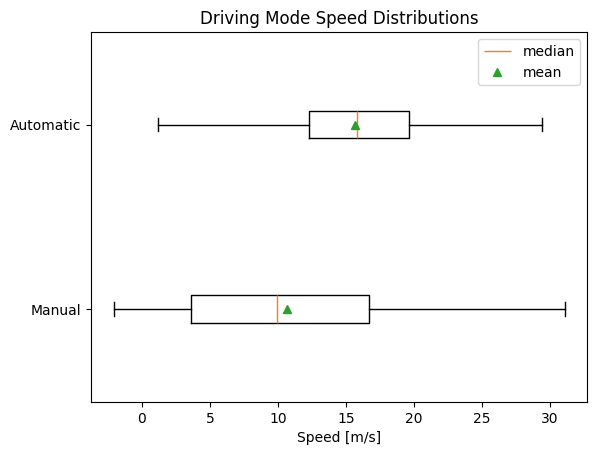

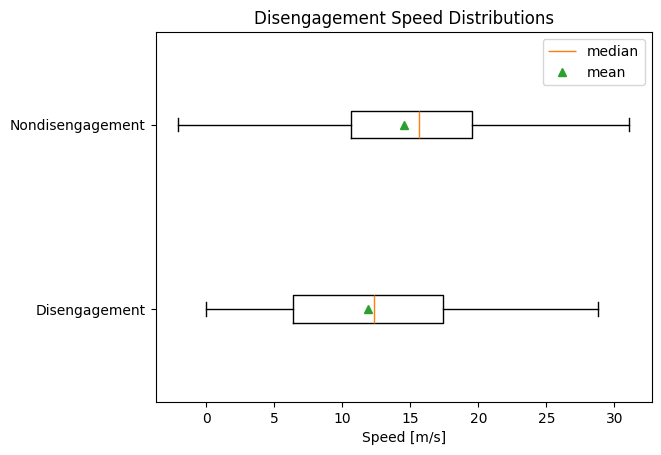

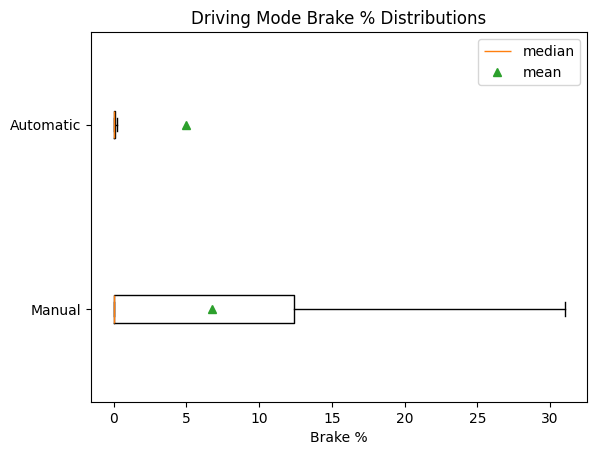

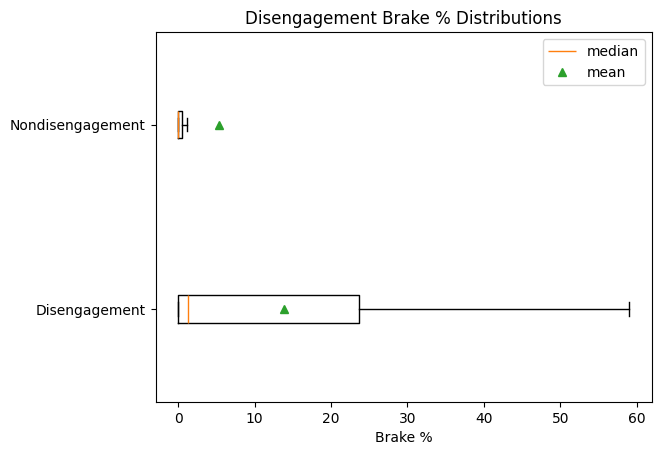

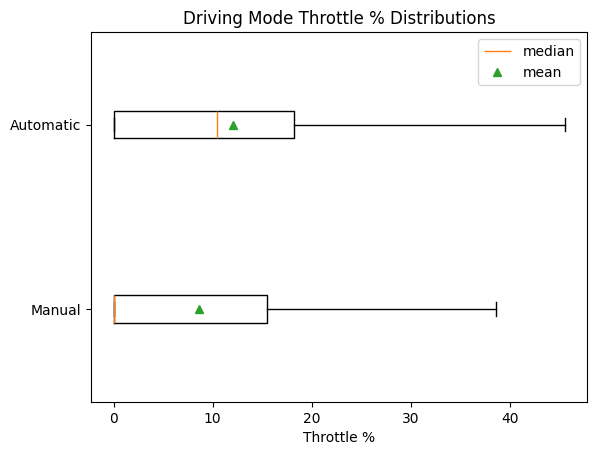

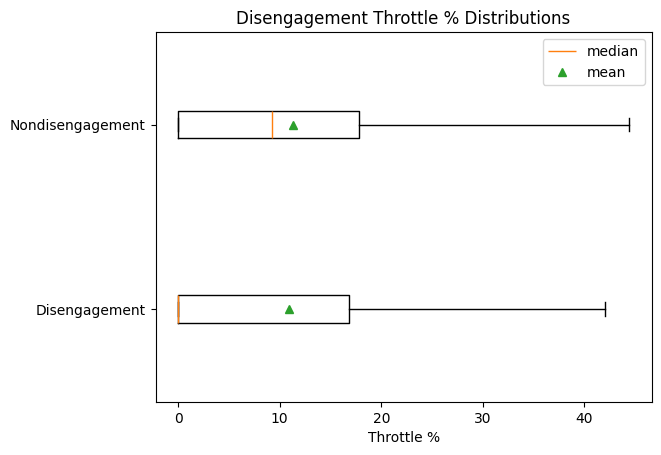

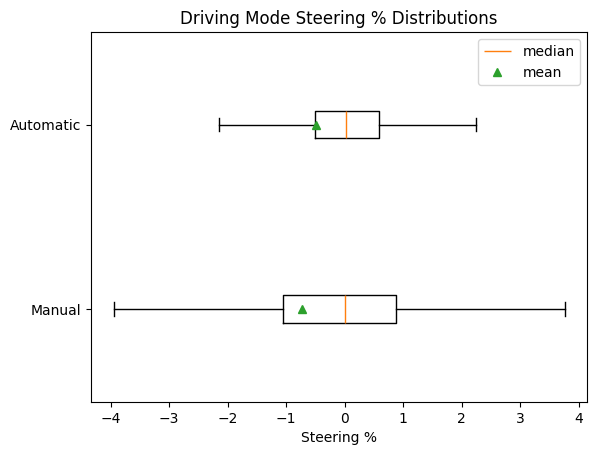

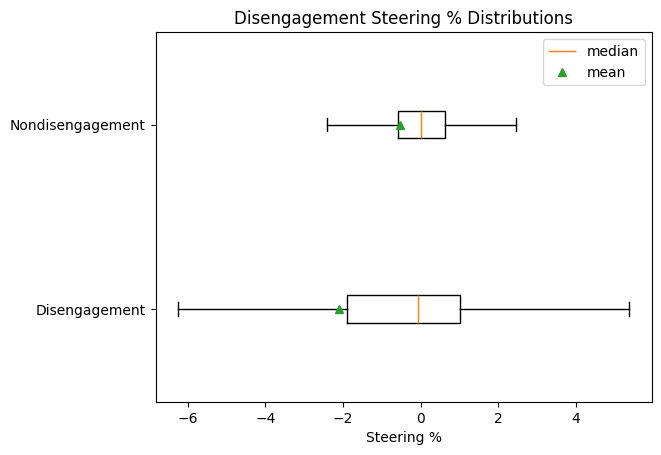

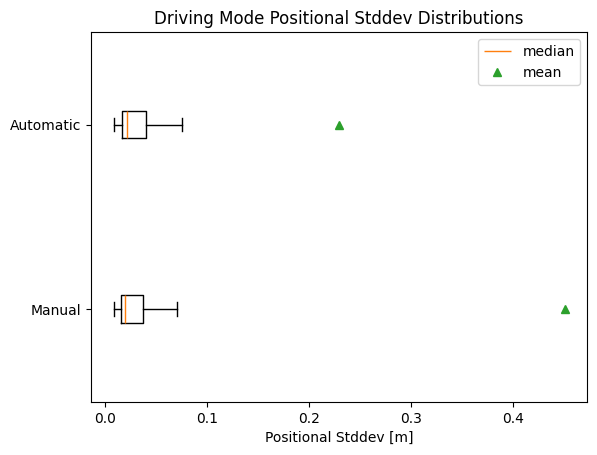

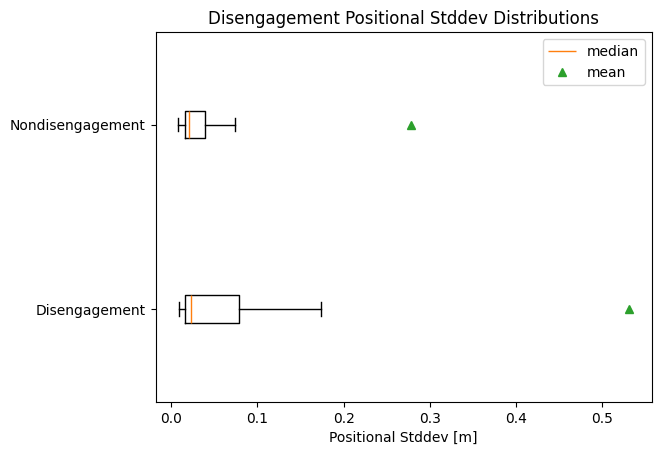

In [9]:
colnames_to_investigate = [ 'speedMps', 'brakePercentage', 'throttlePercentage', 'steeringPercentage', 'LatLonTotalStdDev' ]

xlabels = [ 'Speed [m/s]', 'Brake %', 'Throttle %', 'Steering %', 'Positional Stddev [m]' ]

titles = [ 'Speed', 'Brake %', 'Throttle %', 'Steering %', 'Positional Stddev' ]

#

for colname, xlabel, title in zip( colnames_to_investigate, xlabels, titles ):

    #

    data_drivingmode = [ all_gmIDs_df_manual[ colname ], all_gmIDs_df_auto[ colname ] ]

    data_disengagement = [ all_gmIDs_df_disengagement_expanded[ colname ], all_gmIDs_df_nondisengagement_expanded[ colname ] ]

    #

    plt.title( f'Driving Mode { title } Distributions' )

    bp = plt.boxplot( data_drivingmode, vert = False, showfliers = False, showmeans = True )

    plt.yticks( [ 1, 2 ], [ 'Manual', 'Automatic' ] )

    plt.xlabel( xlabel )

    plt.legend( [ bp[ 'medians' ][ 0 ] , bp[ 'means' ][ 0 ] ], [ 'median', 'mean' ] )

    plt.show()

    #

    plt.title( f'Disengagement { title } Distributions' )

    bp = plt.boxplot( data_disengagement, vert = False, showfliers = False, showmeans = True )

    plt.yticks( [ 1, 2 ], [ 'Disengagement', 'Nondisengagement' ] )

    plt.xlabel( xlabel )

    plt.legend( [ bp[ 'medians' ][ 0 ] , bp[ 'means' ][ 0 ] ], [ 'median', 'mean' ] )

    plt.show()

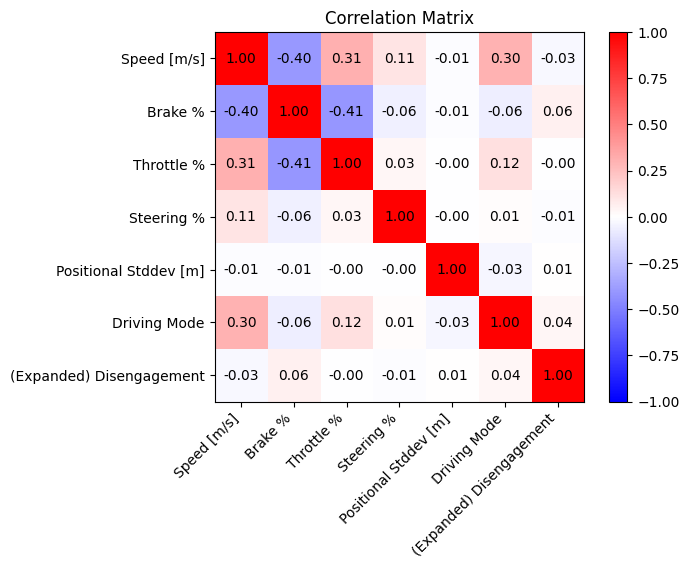

In [37]:
df_to_investigate = all_gmIDs_df[ colnames_to_investigate + [ 'BinaryDrivingMode', 'BinaryDisengagementExpanded' ] ]

#

correlation_matrix = df_to_investigate.corr()

#

plt.imshow( correlation_matrix, cmap = 'bwr', vmin = -1, vmax = 1 )

plt.colorbar()

#

variables = xlabels + [ 'Driving Mode', '(Expanded) Disengagement' ]

#

plt.xticks( range( len( correlation_matrix ) ), variables, rotation = 45, ha = 'right' )

plt.yticks( range( len( correlation_matrix ) ) , variables )

#

correlation_matrix = np.array( correlation_matrix )

for i in range( correlation_matrix.shape[ 0 ] ):
    
    for j in range( correlation_matrix.shape[ 1 ] ):

        val = correlation_matrix[ i, j ]

        val = f'{ correlation_matrix[ i, j ]:.2f}'
        
        text = plt.text( j, i, val, ha = 'center', va = 'center', color = "black" )

#

plt.title( 'Correlation Matrix' )

plt.show()

In [38]:
red_gmIDs = []

green_gmIDs = []

blue_gmIDs = []

for gmID in cfs.list_whitelisted_gmIDs():

    if cfs.give_route( gmID ) == 'Red':

        red_gmIDs.append( gmID )

    elif cfs.give_route( gmID ) == 'Green':

        green_gmIDs.append( gmID )

    else:

        blue_gmIDs.append( gmID )

In [39]:
print( len( red_gmIDs ), len( green_gmIDs ), len( blue_gmIDs ) )

69 81 97


In [2]:
gmID_list = cfs.list_whitelisted_gmIDs()

gmID_dfs_list = [ cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = gmID, moving_window = 0 ) for gmID in gmID_list ]

all_gmIDs_df = pd.concat( gmID_dfs_list )

In [3]:
all_gmIDs_df[ 'BinaryDisengagementExpanded' ].value_counts()

BinaryDisengagementExpanded
0    11353734
1       73090
Name: count, dtype: int64

In [5]:
len( all_gmIDs_df[ all_gmIDs_df[ 'BinaryDisengagement' ] == 1 ] ) / len( all_gmIDs_df[ all_gmIDs_df[ 'BinaryDisengagement' ] == 0 ] )

0.0001940548151897041